Load TSLA Data

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")
from src import DataLoader, EDA, StationarityTester, RiskMetrics, ARIMAForecaster
import pandas as pd

In [2]:
loader = DataLoader(["TSLA"], "2015-01-01", "2026-01-15")
loader.load_processed()
df = loader.data["TSLA"]
price = df['Close']
returns = price.pct_change().dropna()

 Train/Test Split

In [3]:
train_end = "2024-12-31"
train_ret = returns.loc[:train_end]
test_ret = returns.loc[train_end:].iloc[1:]
train_price = price.loc[:train_end]
test_price = price.loc[train_end:].iloc[1:]

Fit ARIMA

In [4]:
forecaster = ARIMAForecaster(train_ret, test_ret, order=(1,0,1))
forecaster.fit()
forecaster.forecast()
forecaster.convert_to_prices(train_price.iloc[-1])
forecaster.evaluate(test_price)

e:\DS_Courses\KAIM_10_Academy\KAIM_8\Week_9\KAIM_Week9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
e:\DS_Courses\KAIM_10_Academy\KAIM_8\Week_9\KAIM_Week9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
e:\DS_Courses\KAIM_10_Academy\KAIM_8\Week_9\KAIM_Week9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 3651
Model:                 ARIMA(1, 0, 1)   Log Likelihood                8079.047
Date:                Mon, 26 Jan 2026   AIC                         -16150.094
Time:                        00:09:48   BIC                         -16125.283
Sample:                    01-03-2015   HQIC                        -16141.258
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.001      2.386      0.017       0.000       0.002
ar.L1          0.5623      0.097      5.772      0.000       0.371       0.753
ma.L1         -0.4758      0.105     -4.520      0.0

{'MAE': 153.28015749990564,
 'RMSE': np.float64(163.6064332523996),
 'MAPE': np.float64(45.81830965307375)}

Plot

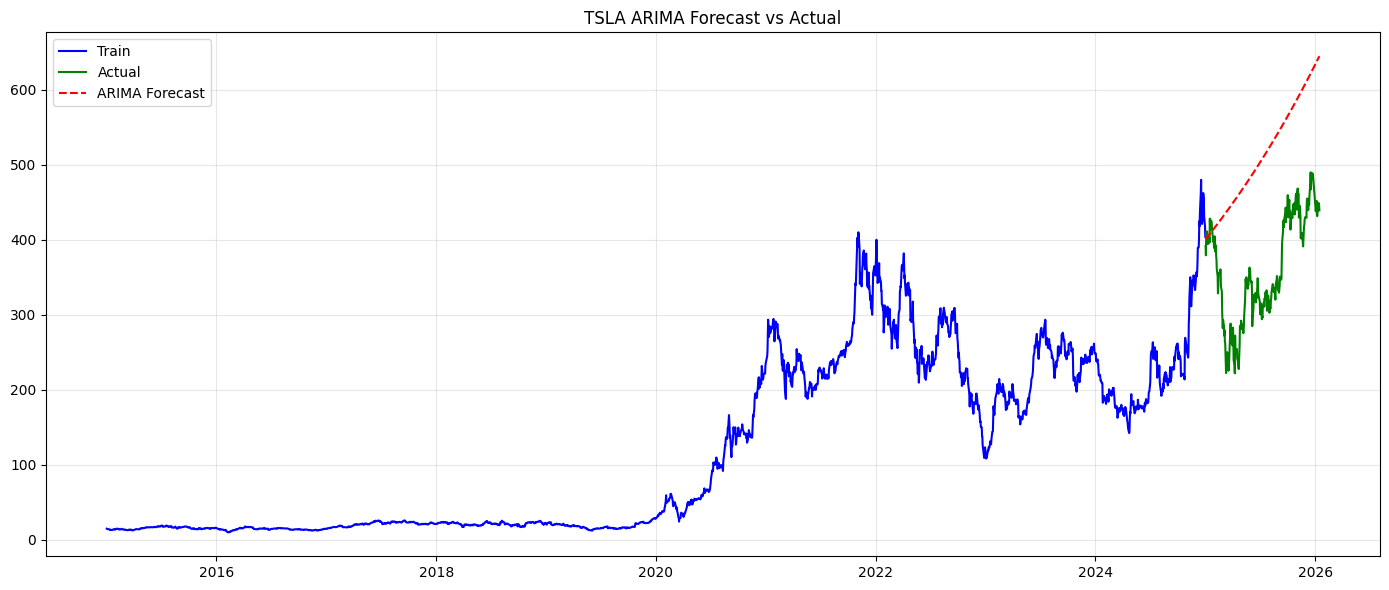

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(train_price.index, train_price.values, label="Train", color='blue')
plt.plot(test_price.index, test_price.values, label="Actual", color='green')
plt.plot(forecaster.forecast_prices.index, forecaster.forecast_prices.values, 
         label="ARIMA Forecast", color='red', linestyle='--')
plt.title("TSLA ARIMA Forecast vs Actual")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()